# Rectangular Waveguide Analysis

This notebook demonstrates a complete rectangular waveguide analysis workflow:

1. Geometry creation
2. Frequency-domain analysis
3. Model order reduction
4. Comparison with analytical solution

In [1]:
from utils.visualization import *
from geometry.primitives import RectangularWaveguide
from solvers.frequency_domain import FrequencyDomainSolver
from rom.reduction import ModelOrderReduction
from analytical.rectangular_waveguide import RWGAnalytical
from ngsolve.webgui import Draw # must import Draw, otherwise may run into problems showing mesh

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

In [2]:
# %%time
# %%timeit -n 3 -r 5
# %time modes, basis = solver.solve(nmodes=3)

## 1. Define Geometry

Create a rectangular waveguide with specified dimensions and mesh parameters.

In [3]:
# Waveguide parameters
a = 100e-3  # Width: 100 mm
L = 200e-3  # Length: 200 mm
maxh = 0.04  # Mesh size

# Create waveguide geometry
rwg = RectangularWaveguide(a=a, L=L, maxh=maxh)
# save step file
rwg.save_step(r"./rectangular_waveguide.step")

print(f"Dimensions: a={a * 1e3:.0f}mm, b={rwg.b * 1e3:.0f}mm, L={L * 1e3:.0f}mm")
print(f"Cutoff frequency (TE10): {rwg.cutoff_frequency_TE10 / 1e9:.3f} GHz")
print(f"Mesh DOFs: ~{rwg.mesh.nv} vertices")

rwg.show('mesh')

Geometry saved to: rectangular_waveguide.step
Dimensions: a=100mm, b=50mm, L=200mm
Cutoff frequency (TE10): 1.499 GHz
Mesh DOFs: ~48 vertices


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…

## 2. Full-Order Numerical Solution

Run a full-order finite element frequency sweep.


Structure Topology
Type: Single structure
Domains (1): ['vacuum']
Total Ports (2): ['port1', 'port2']

Domain-Port Mapping:
  vacuum: ['port1 (external, input)', 'port2 (external, output)']

Assembling Matrices...

Solving port eigenmodes...

	Calculating Port Eigenmodes...
	  Mode source: analytic
	  Polarization angle: 0.0°
	  Requested modes per port: 2
	------------------------------------------------------------
	  port1: rectangular (fit error: 0.0000)
	    a=0.100000, b=0.050000
	  port2: rectangular (fit error: 0.0000)
	    a=0.100000, b=0.050000
	  Precomputing boundary mass matrices (once per port)...
	    Done for 2 port(s)
	port1 mode 0: TE_10, kc=31.4159, σ=+1
	port1 mode 1: TE_01, kc=62.8319, σ=+1
	port2 mode 0: TE_10, kc=31.4159, σ=-1
	port2 mode 1: TE_01, kc=62.8319, σ=-1
	------------------------------------------------------------
	Total modes: 4

--- Assembling Per-Domain Matrices ---

Domain: vacuum
  FES ndof: 2900
  K shape: (2900, 2900), nnz: 271120
  M shape: (

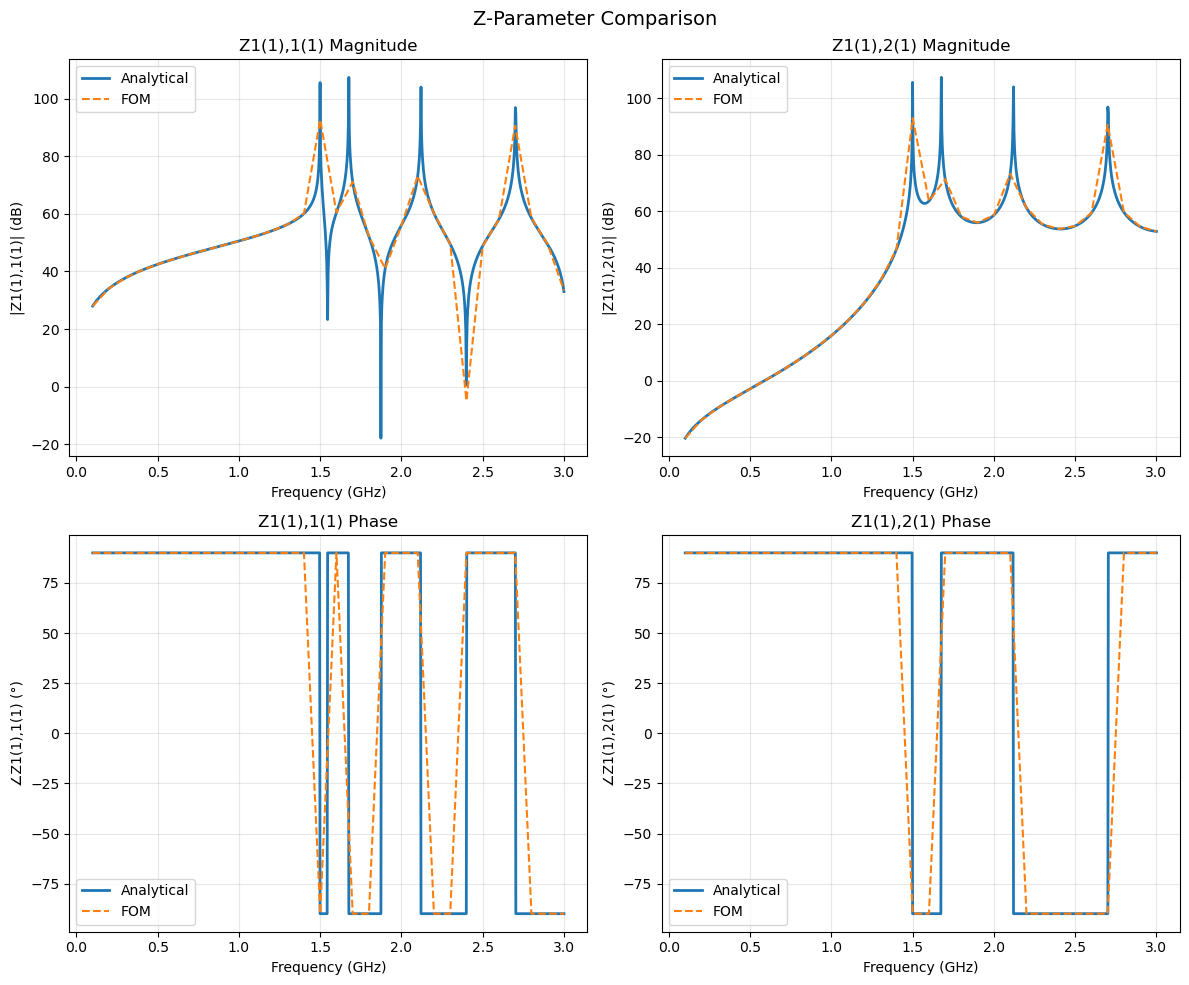

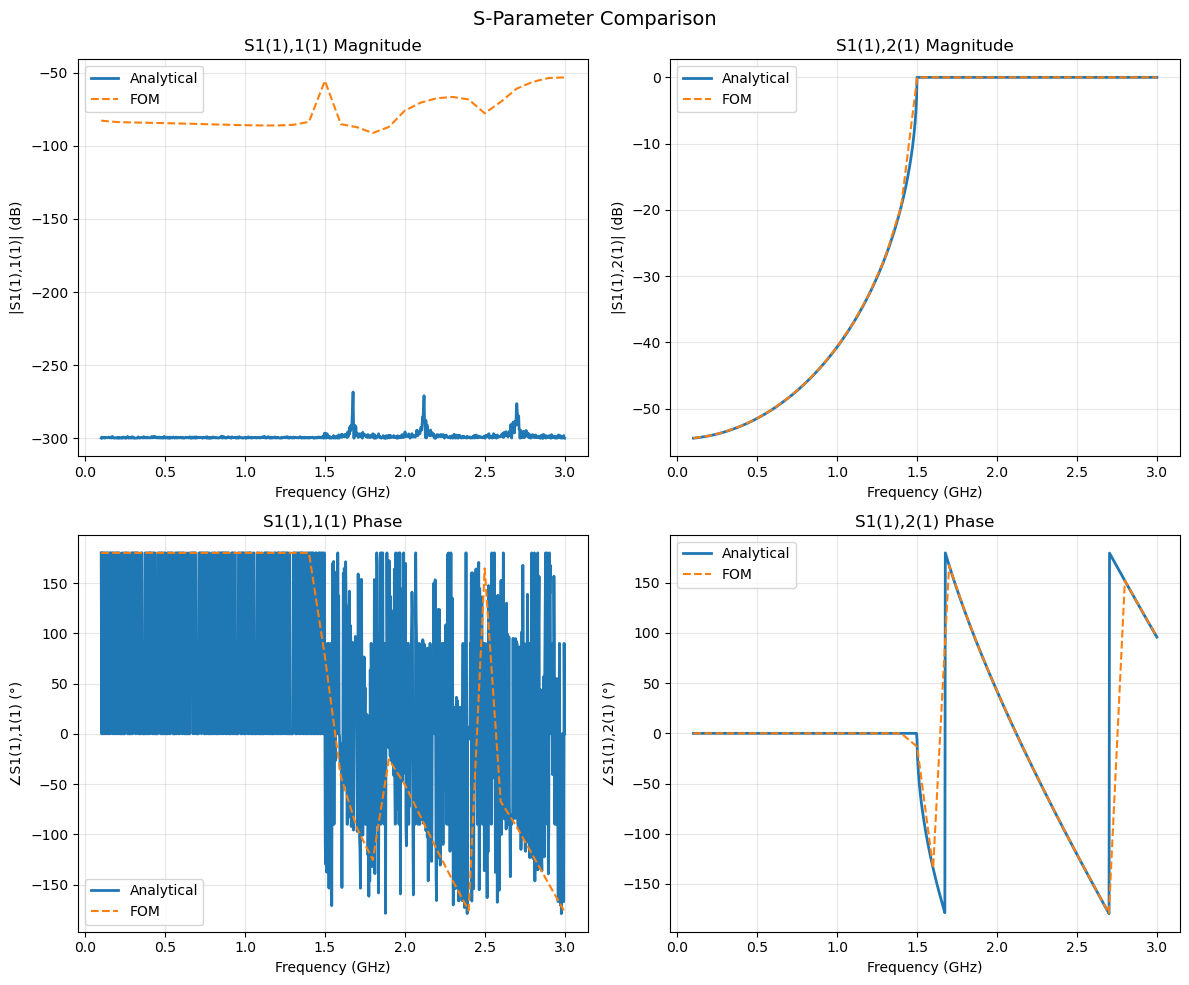

(<Figure size 1200x1000 with 4 Axes>,
 {'S1(1),1(1)_mag': <Axes: title={'center': 'S1(1),1(1) Magnitude'}, xlabel='Frequency (GHz)', ylabel='|S1(1),1(1)| (dB)'>,
  'S1(1),1(1)_phase': <Axes: title={'center': 'S1(1),1(1) Phase'}, xlabel='Frequency (GHz)', ylabel='∠S1(1),1(1) (°)'>,
  'S1(1),2(1)_mag': <Axes: title={'center': 'S1(1),2(1) Magnitude'}, xlabel='Frequency (GHz)', ylabel='|S1(1),2(1)| (dB)'>,
  'S1(1),2(1)_phase': <Axes: title={'center': 'S1(1),2(1) Phase'}, xlabel='Frequency (GHz)', ylabel='∠S1(1),2(1) (°)'>})

In [4]:
# 2. Analytical
a = 100e-3  # Width: 100 mm
L = 200e-3  # Length: 200 mm
analytical = RWGAnalytical(a=a, L=L)


# 3. FOM solve
fmin, fmax, nf = 0.1, 3, 30
fds = FrequencyDomainSolver(rwg, order=3)
fds.assemble_matrices(nportmodes=2)
fds.solve(fmin, fmax, nf, store_snapshots=True)

# 4. Quick comparison plots - just pass the objects!
frequencies = np.linspace(fmin, fmax, 1000) * 1e9
plot_z_comparison([analytical, fds], frequencies=frequencies)
plot_s_comparison([analytical, fds], frequencies=frequencies)

In [5]:
print(fds.Z_dict['2(1)1(1)'])
print(fds.Z_dict['1(1)2(1)'])

[ 0.+9.54014527e-02j  0.+2.00371450e-01j  0.+3.26372768e-01j
  0.+4.89280662e-01j  0.+7.13464488e-01j  0.+1.03923614e+00j
  0.+1.53759494e+00j  0.+2.34163835e+00j  0.+3.71911430e+00j
  0.+6.25746375e+00j  0.+1.14011762e+01j  0.+2.33241633e+01j
  0.+5.76002041e+01j  0.+2.10915705e+02j -0.-4.41888169e+04j
 -0.-1.50726287e+03j  0.+3.66387768e+03j  0.+7.91171561e+02j
  0.+6.23305802e+02j  0.+8.50052007e+02j  0.+4.54634763e+03j
 -0.-1.14462541e+03j -0.-5.79792248e+02j -0.-4.82202210e+02j
 -0.-5.45782764e+02j -0.-9.25051126e+02j -0.-3.37300883e+04j
  0.+9.53500162e+02j  0.+5.29581825e+02j  0.+4.36480140e+02j]
[ 0.+9.54014527e-02j  0.+2.00371450e-01j  0.+3.26372768e-01j
  0.+4.89280662e-01j  0.+7.13464488e-01j  0.+1.03923614e+00j
  0.+1.53759494e+00j  0.+2.34163835e+00j  0.+3.71911430e+00j
  0.+6.25746375e+00j  0.+1.14011762e+01j  0.+2.33241633e+01j
  0.+5.76002041e+01j  0.+2.10915705e+02j -0.-4.41888169e+04j
 -0.-1.50726287e+03j  0.+3.66387768e+03j  0.+7.91171561e+02j
  0.+6.23305802e+02j  0

In [6]:
for k, v in fds.Z_dict.items():
    print(f'{k}: {20 * np.log10(np.abs(v)) + 1e-15}')

frequencies: [160.         166.02059991 169.54242509 172.04119983 173.97940009
 175.56302501 176.9019608  178.06179974 179.08485019 180.
 180.8278537  181.58362492 182.27886705 182.92256071 183.52182518
 184.08239965 184.60897843 185.1054501  185.57507202 186.02059991
 186.44438589 186.84845362 187.23455672 187.60422483 187.95880017
 188.29946696 188.62727528 188.94316063 189.24795996 189.54242509]
1(1)1(1): [28.02308817 34.10249909 37.72390715 40.36601664 42.49573284 44.32551752
 45.97459756 47.52222253 49.0312696  50.56315658 52.19391622 54.04481287
 56.37452295 60.06015796 92.66918734 60.45787291 71.06762395 52.12109262
 41.00511693 56.00525524 73.09171685 60.19451233 49.52906248 -4.83171853
 48.82778671 58.08077361 90.55900838 58.5212032  49.43129235 33.41441723]
1(2)1(1): [-21.03468014 -13.54935378  -9.68973877  -6.96451975  -4.7952799
  -2.94276968  -1.27872258   0.279817     1.79743432   3.33637836
   4.97307075   6.82889889   9.16243527  12.8502628   45.45569234
  13.25853486  

In [7]:
count = 0
for p in (1, 2):
    for q in (1, 2):
        for m in [1, 2]:
            for n in [1, 2]:
                print(count, fr'{p}({m}){q}({n})')
                count += 1

0 1(1)1(1)
1 1(1)1(2)
2 1(2)1(1)
3 1(2)1(2)
4 1(1)2(1)
5 1(1)2(2)
6 1(2)2(1)
7 1(2)2(2)
8 2(1)1(1)
9 2(1)1(2)
10 2(2)1(1)
11 2(2)1(2)
12 2(1)2(1)
13 2(1)2(2)
14 2(2)2(1)
15 2(2)2(2)


In [8]:
fds.n_ports

2

In [9]:
fds.port_solver.port_mass_matrices['port2'].shape

(2900, 2900)

In [10]:
fds.port_solver.port_orientation_factors

{'port1': 1.0, 'port2': -1.0}

In [11]:
fds.plot_port_mode('port1')


Port Mode: port1 [external (input)], Mode 0
Cutoff frequency: 1.4990 GHz


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…

In [12]:
fds.plot_port_mode('port2')


Port Mode: port2 [external (output)], Mode 0
Cutoff frequency: 1.4990 GHz


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…

In [13]:
# # 6. Eigenfrequency comparison
# fig, ax = plot_eigenfrequencies([fds], analytical=analytical, n_modes=35)
# ax.set_ylim(1, 5)
# ax.set_xlim(1, 5)

CPU times: total: 0 ns
Wall time: 0 ns

Model Order Reduction

Domain: vacuum
  Using global snapshots (single-domain structure)
  Full DOFs: 2900
  Snapshots: 120
  Reduced DOFs: 27
  Compression: 99.1%
  Singular value decay: 5.81e+05 → 3.04e-01

------------------------------------------------------------
Total: 2900 → 27 DOFs
Overall compression: 99.1%
CPU times: total: 93.8 ms
Wall time: 86.8 ms
CPU times: total: 2.66 s
Wall time: 1.18 s


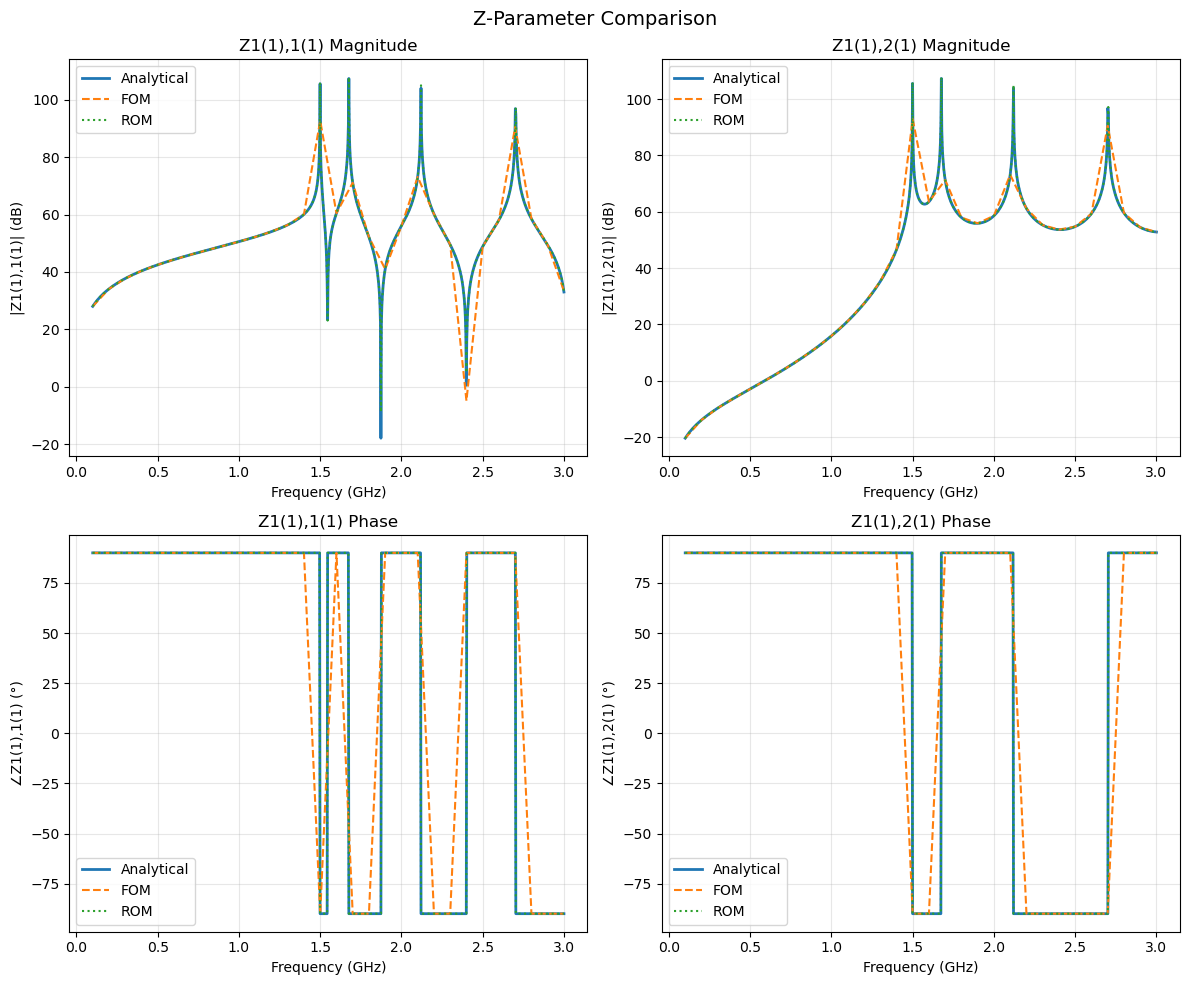

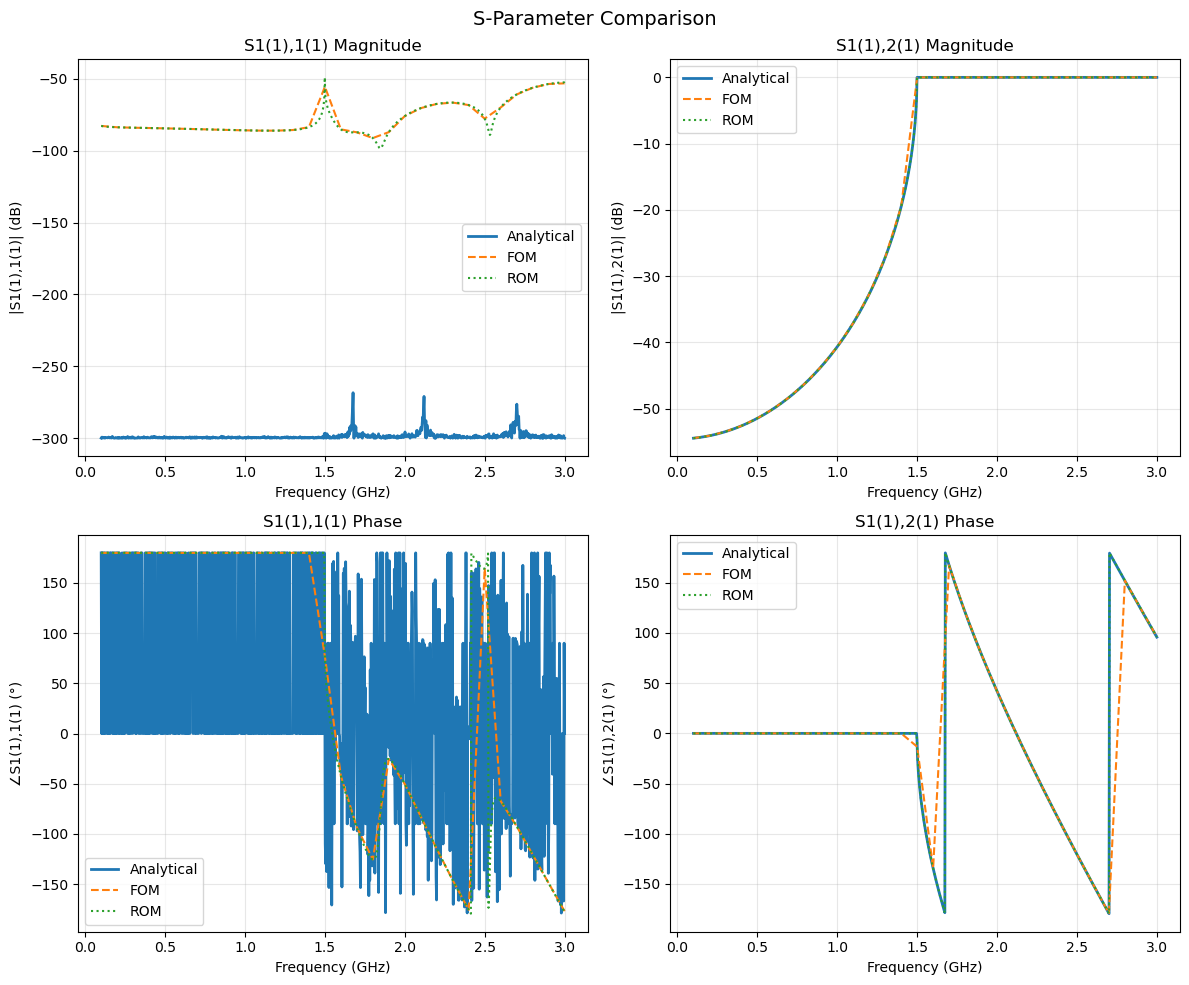

(<Figure size 1200x1000 with 4 Axes>,
 {'S1(1),1(1)_mag': <Axes: title={'center': 'S1(1),1(1) Magnitude'}, xlabel='Frequency (GHz)', ylabel='|S1(1),1(1)| (dB)'>,
  'S1(1),1(1)_phase': <Axes: title={'center': 'S1(1),1(1) Phase'}, xlabel='Frequency (GHz)', ylabel='∠S1(1),1(1) (°)'>,
  'S1(1),2(1)_mag': <Axes: title={'center': 'S1(1),2(1) Magnitude'}, xlabel='Frequency (GHz)', ylabel='|S1(1),2(1)| (dB)'>,
  'S1(1),2(1)_phase': <Axes: title={'center': 'S1(1),2(1) Phase'}, xlabel='Frequency (GHz)', ylabel='∠S1(1),2(1) (°)'>})

In [14]:
# After ROM is working...
from rom.reduction import ModelOrderReduction

%time rom = ModelOrderReduction(fds)
%time rom.reduce(max_rank=30, tol=1e-6)
%time rom.solve(0.1, 3, 1000)

# Compare all three
plot_z_comparison([analytical, fds, rom], frequencies=frequencies,
                  labels=['Analytical', 'FOM', 'ROM'])
plot_s_comparison([analytical, fds, rom], frequencies=frequencies,
                  labels=['Analytical', 'FOM', 'ROM'])


(1.0, 5.0)

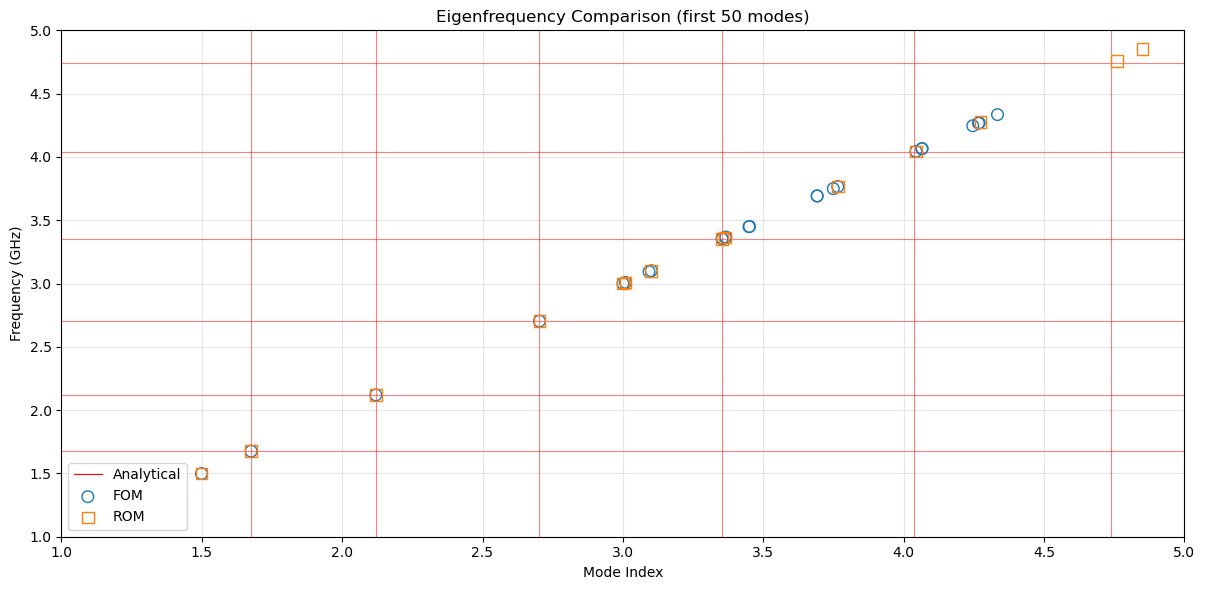

In [15]:
fig, ax = plot_eigenfrequencies([fds, rom], analytical=analytical,
                      labels=['FOM', 'ROM'], n_modes=50)
ax.set_ylim(1, 5)
ax.set_xlim(1, 5)

## 4. Model Order Reduction

Build a reduced-order model using Proper Orthogonal Decomposition (POD).

In [16]:
# Build reduced-order model
rom = ModelOrderReduction(solver.M, solver.K, solver.B)
A_r, B_r, W = rom.reduce(solver.snapshots, tol=1e-6)

print(f"Original dimension: {solver.M.shape[0]}")
print(f"Reduced dimension: {rom.r}")
print(f"Compression ratio: {solver.M.shape[0] / rom.r:.1f}x")

NameError: name 'solver' is not defined

In [ ]:
# Create wave impedance function from port solver
def wave_impedance_func(freq):
    return solver.port_solver.get_wave_impedance_matrix(freq)

# Solve ROM
Z_reduced = rom.solve_reduced(frequencies, wave_impedance_func=wave_impedance_func)

print(f"ROM solved at {len(frequencies)} points")
print(f"Z shape: {Z_reduced['Z'].shape}")
print(f"S shape: {Z_reduced['S'].shape}")

## 5. Comparison and Plotting

Compare Z-parameters from analytical, full FEM, and ROM solutions.

In [ ]:
plotter = ZParameterPlotter(figsize=(12, 10))
plotter.setup_figure()
plotter.plot_comparison(Z_analytical, Z_full, Z_reduced)
plt.suptitle('Z-Parameter Comparison', fontsize=14)
plt.show()

In [ ]:
plotter = SParameterPlotter(figsize=(12, 10))
plotter.setup_figure()
plotter.plot_comparison(S_analytical, S_full, Z_reduced)
plt.suptitle('S-Parameter Comparison', fontsize=14)
plt.show()

In [ ]:
ports = list(solver.port_modes.keys())
Zw_numerical = np.array([solver.port_solver.get_wave_impedance(ports[0], 0, f) for f in frequencies])
Zw_analytical = analytical.wave_impedance(frequencies)

# Plot
fig, ax = WaveImpedancePlotter.quick_plot(
    frequencies, Zw_analytical, Zw_numerical,
    cutoff_freq=analytical.fc,
    title='TE₁₀ Wave Impedance'
)
plt.show()

In [ ]:
# Singular value decay plot
fig2, ax2 = plt.subplots(figsize=(8, 5))

ConvergencePlotter.plot_singular_values(
    rom._singular_values,
    truncation_rank=rom.r,
    ax=ax2
)

plt.title('POD Singular Value Decay')
plt.tight_layout()
plt.show()

## 6. Error Analysis

Quantify the error between numerical solutions and the analytical reference.

In [ ]:
# ROM error
Z_ana_rom = analytical.z_parameters(Z_reduced['frequencies'])
Z11_rom = Z_reduced['Z'][:, 0, 0]
Z11_ana_rom = Z_ana_rom['Z11']

rel_error_rom = np.abs(Z11_rom - Z11_ana_rom) / np.abs(Z11_ana_rom)

print("ROM vs Analytical:")
print(f"   Mean relative error: {np.mean(rel_error_rom) * 100:.2f}%")
print(f"   Max relative error:  {np.max(rel_error_rom) * 100:.2f}%")

## 7. Eigenfrequency Comparison

Compare eigenfrequencies from the ROM with analytical values.

In [ ]:
# Get ROM eigenfrequencies
eigs_rom = rom.get_eigenvalues()
freqs_rom = np.sqrt(np.abs(eigs_rom)) / (2 * np.pi)
freqs_rom_ghz = freqs_rom / 1e9

print("ROM eigenfrequencies (GHz):")
for i, f in enumerate(sorted(freqs_rom_ghz)[:10]):
    print(f"   Mode {i + 1}: {f:.4f} GHz")

In [ ]:
from analytical.rectangular_waveguide import RWGAnalytical

# Create analytical model
analytical = RWGAnalytical(a=100e-3, L=200e-3, b=50e-3)

# Get detailed list with degeneracy info
freq_list = analytical.all_eigenfrequencies(n_modes=20, return_format='list')
for f, k, mode_str, modes in freq_list:
    print(f"{f/1e9:.4f} GHz - {mode_str}")

## Summary

This analysis demonstrated:
- **Geometry creation** for a rectangular waveguide
- **Full-order FEM** frequency domain analysis
- **Model order reduction** using POD with significant compression
- **Validation** against analytical solutions

The ROM provides accurate results with substantially reduced computational cost.

In [ ]:
# Optional: Save figures to files
# Uncomment to save

# fig.savefig('rwg_z_parameters.png', dpi=150, bbox_inches='tight')
# fig2.savefig('rwg_singular_values.png', dpi=150, bbox_inches='tight')
# print("Figures saved!")

In [ ]:
"""
Diagnostic script for port eigenmode solver.
Run this after creating your geometry and solver.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jnp_zeros, jn_zeros

from ngsolve import (
    Integrate, InnerProduct, BND, CoefficientFunction, specialcf,
    x, y, z, Mesh, Draw, TaskManager
)

# Import your modules
from solvers.frequency_domain import FrequencyDomainSolver
from solvers.ports import PortEigenmodeSolver
from core.constants import c0, mu0, eps0

# ============================================================
# DIAGNOSTIC CLASS
# ============================================================

class PortModeDiagnostics:
    """Diagnostic tools to verify port eigenmode solutions."""
    
    def __init__(self, port_solver, mesh):
        self.port_solver = port_solver
        self.mesh = mesh
    
    def verify_cutoff_frequencies(self):
        """Print all computed cutoff frequencies."""
        print("\n" + "=" * 70)
        print("CUTOFF FREQUENCY VERIFICATION")
        print("=" * 70)
        
        for port in self.port_solver.port_modes:
            print(f"\nPort: {port}")
            print("-" * 50)
            
            # Get port area
            port_region = self.mesh.Boundaries(port)
            area = Integrate(CoefficientFunction(1), self.mesh, BND, definedon=port_region)
            
            # Get normal
            normal = self.port_solver.port_normals.get(port, np.array([0, 0, 1]))
            
            print(f"  Port area: {area*1e6:.4f} mm²")
            print(f"  Port normal: [{normal[0]:.3f}, {normal[1]:.3f}, {normal[2]:.3f}]")
            
            for mode_idx, kc in self.port_solver.port_cutoff_kc[port].items():
                fc = c0 * kc / (2 * np.pi)
                print(f"  Mode {mode_idx}: kc = {kc:.4f} rad/m, fc = {fc/1e9:.6f} GHz")
    
    def check_mode_orthogonality(self, port: str):
        """Verify modes are orthonormal on a port."""
        print(f"\nOrthogonality check for {port}:")
        print("-" * 40)
        
        modes = self.port_solver.port_modes[port]
        port_region = self.mesh.Boundaries(port)
        
        n_modes = len(modes)
        overlap = np.zeros((n_modes, n_modes))
        
        for i in range(n_modes):
            for j in range(n_modes):
                val = Integrate(
                    InnerProduct(modes[i], modes[j]),
                    self.mesh, BND, definedon=port_region
                )
                overlap[i, j] = np.real(val)
        
        print("  Overlap matrix (should be identity):")
        for i in range(n_modes):
            row_str = "  [" + ", ".join([f"{overlap[i,j]:+.4f}" for j in range(n_modes)]) + "]"
            print(row_str)
        
        # Check if close to identity
        identity_error = np.linalg.norm(overlap - np.eye(n_modes))
        print(f"\n  Frobenius norm of (Overlap - I): {identity_error:.2e}")
        if identity_error > 0.01:
            print("  ⚠️  WARNING: Modes are not properly orthonormal!")
        else:
            print("  ✓ Modes are orthonormal")
        
        return overlap
    
    def check_mode_normalization(self, port: str):
        """Verify each mode has unit norm."""
        print(f"\nNormalization check for {port}:")
        print("-" * 40)
        
        modes = self.port_solver.port_modes[port]
        port_region = self.mesh.Boundaries(port)
        
        for mode_idx, mode in modes.items():
            norm_sq = Integrate(
                InnerProduct(mode, mode),
                self.mesh, BND, definedon=port_region
            )
            print(f"  Mode {mode_idx}: ||E||² = {np.real(norm_sq):.6f} (should be 1.0)")
    
    def compare_with_analytical_circular(self, port: str, radius: float):
        """Compare computed modes with analytical TE modes for circular waveguide."""
        print(f"\n" + "=" * 70)
        print(f"ANALYTICAL COMPARISON - CIRCULAR WAVEGUIDE")
        print(f"Radius = {radius*1000:.2f} mm")
        print("=" * 70)
        
        # Analytical TE mode cutoffs: kc = p'_mn / a
        # where p'_mn is the n-th root of J'_m(x) = 0
        
        # First few TE modes
        analytical_modes = []
        
        # TE_1n modes (m=1)
        p_prime_1 = jnp_zeros(1, 3)  # First 3 roots of J'_1
        for n, p in enumerate(p_prime_1, 1):
            kc = p / radius
            fc = c0 * kc / (2 * np.pi)
            analytical_modes.append(('TE', 1, n, kc, fc))
        
        # TE_0n modes (m=0) - these are TM-like in the transverse plane
        p_prime_0 = jnp_zeros(0, 2)  # First 2 roots of J'_0 = -J_1
        for n, p in enumerate(p_prime_0, 1):
            kc = p / radius
            fc = c0 * kc / (2 * np.pi)
            analytical_modes.append(('TE', 0, n, kc, fc))
        
        # TE_2n modes (m=2)
        p_prime_2 = jnp_zeros(2, 2)
        for n, p in enumerate(p_prime_2, 1):
            kc = p / radius
            fc = c0 * kc / (2 * np.pi)
            analytical_modes.append(('TE', 2, n, kc, fc))
        
        # Sort by cutoff frequency
        analytical_modes.sort(key=lambda x: x[4])
        
        print("\nAnalytical TE mode cutoffs (sorted by fc):")
        print("-" * 50)
        for mode_type, m, n, kc, fc in analytical_modes[:6]:
            p_val = kc * radius
            print(f"  {mode_type}_{m}{n}: p'_{m}{n} = {p_val:.4f}, "
                  f"kc = {kc:.4f} rad/m, fc = {fc/1e9:.4f} GHz")
        
        # Compare with computed
        print(f"\nComputed cutoffs for {port}:")
        print("-" * 50)
        computed_kc = []
        for mode_idx, kc in sorted(self.port_solver.port_cutoff_kc[port].items()):
            fc = c0 * kc / (2 * np.pi)
            computed_kc.append(kc)
            print(f"  Mode {mode_idx}: kc = {kc:.4f} rad/m, fc = {fc/1e9:.4f} GHz")
        
        # Try to match modes
        print("\nMode matching:")
        print("-" * 50)
        for i, kc_comp in enumerate(computed_kc):
            # Find closest analytical mode
            best_match = None
            best_error = float('inf')
            for mode_type, m, n, kc_ana, fc_ana in analytical_modes:
                error = abs(kc_comp - kc_ana) / kc_ana
                if error < best_error:
                    best_error = error
                    best_match = (mode_type, m, n, kc_ana)
            
            if best_match:
                mode_type, m, n, kc_ana = best_match
                print(f"  Computed mode {i} ↔ {mode_type}_{m}{n}: "
                      f"error = {best_error*100:.2f}%")
                if best_error > 0.05:
                    print(f"      ⚠️  Large error! Check mesh resolution.")
    
    def compare_with_analytical_rectangular(self, port: str, a: float, b: float):
        """Compare computed modes with analytical TE modes for rectangular waveguide."""
        print(f"\n" + "=" * 70)
        print(f"ANALYTICAL COMPARISON - RECTANGULAR WAVEGUIDE")
        print(f"a = {a*1000:.2f} mm, b = {b*1000:.2f} mm")
        print("=" * 70)
        
        # Analytical TE_mn cutoffs: kc = sqrt((mπ/a)² + (nπ/b)²)
        # TE_10 is dominant mode for a > b
        
        analytical_modes = []
        for m in range(4):
            for n in range(4):
                if m == 0 and n == 0:
                    continue  # No TE_00 mode
                kc = np.sqrt((m * np.pi / a)**2 + (n * np.pi / b)**2)
                fc = c0 * kc / (2 * np.pi)
                analytical_modes.append(('TE', m, n, kc, fc))
        
        # Sort by cutoff frequency
        analytical_modes.sort(key=lambda x: x[4])
        
        print("\nAnalytical TE mode cutoffs (sorted by fc):")
        print("-" * 50)
        for mode_type, m, n, kc, fc in analytical_modes[:6]:
            print(f"  {mode_type}_{m}{n}: kc = {kc:.4f} rad/m, fc = {fc/1e9:.4f} GHz")
        
        # Compare with computed
        print(f"\nComputed cutoffs for {port}:")
        print("-" * 50)
        computed_kc = []
        for mode_idx, kc in sorted(self.port_solver.port_cutoff_kc[port].items()):
            fc = c0 * kc / (2 * np.pi)
            computed_kc.append(kc)
            print(f"  Mode {mode_idx}: kc = {kc:.4f} rad/m, fc = {fc/1e9:.4f} GHz")
        
        # Match modes
        print("\nMode matching:")
        print("-" * 50)
        for i, kc_comp in enumerate(computed_kc):
            best_match = None
            best_error = float('inf')
            for mode_type, m, n, kc_ana, fc_ana in analytical_modes:
                error = abs(kc_comp - kc_ana) / kc_ana
                if error < best_error:
                    best_error = error
                    best_match = (mode_type, m, n, kc_ana)
            
            if best_match:
                mode_type, m, n, kc_ana = best_match
                print(f"  Computed mode {i} ↔ {mode_type}_{m}{n}: "
                      f"error = {best_error*100:.2f}%")
    
    def print_alignment_info(self):
        """Print detailed alignment information for all ports."""
        print("\n" + "=" * 70)
        print("PORT ALIGNMENT INFORMATION")
        print("=" * 70)
        
        pol_info = self.port_solver.get_polarization_info()
        
        for port in sorted(pol_info.keys()):
            info = pol_info[port]
            print(f"\n{port}:")
            print(f"  Normal vector:        [{info['normal'][0]:+.4f}, "
                  f"{info['normal'][1]:+.4f}, {info['normal'][2]:+.4f}]")
            print(f"  Tangent 1:            [{info['tangent1'][0]:+.4f}, "
                  f"{info['tangent1'][1]:+.4f}, {info['tangent1'][2]:+.4f}]")
            print(f"  Tangent 2:            [{info['tangent2'][0]:+.4f}, "
                  f"{info['tangent2'][1]:+.4f}, {info['tangent2'][2]:+.4f}]")
            print(f"  Polarization vector:  [{info['polarization'][0]:+.4f}, "
                  f"{info['polarization'][1]:+.4f}, {info['polarization'][2]:+.4f}]")
            print(f"  Orientation factor σ: {info['orientation_factor']:+.1f}")
            
            # Compute inward direction
            inward = -info['normal']
            print(f"  Inward direction:     [{inward[0]:+.4f}, "
                  f"{inward[1]:+.4f}, {inward[2]:+.4f}]")
    
    def check_eigenvalue_solver_convergence(self, port: str, nmodes: int = 3):
        """Re-run eigenvalue solver with verbose output to check convergence."""
        from ngsolve import HCurl, BilinearForm, curl, ds, Preconditioner, solvers, IdentityMatrix
        
        print(f"\n" + "=" * 70)
        print(f"EIGENVALUE SOLVER CONVERGENCE CHECK - {port}")
        print("=" * 70)
        
        fes_port = HCurl(
            self.mesh, 
            order=self.port_solver.order,
            dirichlet=self.port_solver.bc,
            definedon=self.mesh.Boundaries(port)
        )
        
        print(f"FE space dimension: {fes_port.ndof}")
        print(f"Free DOFs: {sum(fes_port.FreeDofs())}")
        
        u, v = fes_port.TnT()
        
        a = BilinearForm(curl(u.Trace()) * curl(v.Trace()) * ds(port))
        m = BilinearForm(u.Trace() * v.Trace() * ds(port))
        apre = BilinearForm(
            (curl(u).Trace() * curl(v).Trace() + u.Trace() * v.Trace()) * ds(port)
        )
        pre = Preconditioner(apre, type="direct", inverse="sparsecholesky")
        
        with TaskManager():
            a.Assemble()
            m.Assemble()
            apre.Assemble()
            
            # Gradient projection
            G, fes_h1 = fes_port.CreateGradient()
            GT = G.CreateTranspose()
            math1 = GT @ m.mat @ G
            invh1 = math1.Inverse(inverse="sparsecholesky", freedofs=fes_h1.FreeDofs())
            
            proj = IdentityMatrix(fes_port.ndof) - G @ invh1 @ GT @ m.mat
            projpre = proj @ pre
            
            print("\nRunning PINVIT with verbose output...")
            print("-" * 50)
            
            # Run with more iterations and print rates
            evals, evecs = solvers.PINVIT(
                a.mat, m.mat, pre=projpre,
                num=nmodes + 5,
                maxit=50,
                printrates=True
            )
        
        print("\nRaw eigenvalues (before filtering):")
        for i, ev in enumerate(evals):
            print(f"  λ_{i} = {ev:.6f}")
        
        # Filter
        valid_evals = [(i, ev) for i, ev in enumerate(evals) if ev > 1]
        print(f"\nValid eigenvalues (λ > 1): {len(valid_evals)}")
        for i, ev in valid_evals[:nmodes]:
            kc = np.sqrt(ev)
            fc = c0 * kc / (2 * np.pi)
            print(f"  λ = {ev:.4f}, kc = {kc:.4f} rad/m, fc = {fc/1e9:.4f} GHz")


def check_mesh_quality(mesh, port: str):
    """Check mesh quality on port surface."""
    print(f"\n" + "=" * 70)
    print(f"MESH QUALITY CHECK - {port}")
    print("=" * 70)
    
    port_region = mesh.Boundaries(port)
    
    # Count elements on port
    n_elements = 0
    for el in mesh.Elements(BND):
        # Check if element is on this boundary
        if mesh.GetBoundaries()[el.index] == port:
            n_elements += 1
    
    # Alternative counting method
    from ngsolve import GridFunction, H1
    fes = H1(mesh, order=1)
    indicator = GridFunction(fes)
    indicator.Set(CoefficientFunction(1), definedon=port_region)
    
    # Get port area
    area = Integrate(CoefficientFunction(1), mesh, BND, definedon=port_region)
    
    print(f"  Port area: {area*1e6:.4f} mm²")
    print(f"  Approximate element count: {n_elements}")
    if n_elements > 0:
        avg_element_area = area / max(n_elements, 1)
        avg_element_size = np.sqrt(avg_element_area) * 1000  # in mm
        print(f"  Average element size: ~{avg_element_size:.2f} mm")
    
    # Recommendation based on wavelength
    print("\n  Mesh recommendations:")
    print("  - For accurate eigenvalues, use at least 10 elements across smallest dimension")
    print("  - For curved boundaries (circular), use at least 20-30 elements around circumference")


# ============================================================
# MAIN DIAGNOSTIC RUNNER
# ============================================================

def run_diagnostics_rectangular(solver, a, b):
    """
    Run full diagnostics for rectangular waveguide.
    
    Parameters
    ----------
    solver : FrequencyDomainSolver
        Solver after assemble_matrices() has been called
    a : float
        Waveguide width [m]
    b : float  
        Waveguide height [m]
    """
    print("\n" + "=" * 70)
    print("RECTANGULAR WAVEGUIDE DIAGNOSTICS")
    print("=" * 70)
    
    diag = PortModeDiagnostics(solver.port_solver, solver.mesh)
    
    # 1. Basic info
    diag.verify_cutoff_frequencies()
    
    # 2. Check each port
    for port in solver.port_solver.port_modes:
        diag.check_mode_normalization(port)
        diag.check_mode_orthogonality(port)
        diag.compare_with_analytical_rectangular(port, a, b)
        check_mesh_quality(solver.mesh, port)
    
    # 3. Alignment info
    diag.print_alignment_info()
    
    return diag


def run_diagnostics_circular(solver, radius):
    """
    Run full diagnostics for circular waveguide.
    
    Parameters
    ----------
    solver : FrequencyDomainSolver
        Solver after assemble_matrices() has been called
    radius : float
        Waveguide radius [m]
    """
    print("\n" + "=" * 70)
    print("CIRCULAR WAVEGUIDE DIAGNOSTICS")
    print("=" * 70)
    
    diag = PortModeDiagnostics(solver.port_solver, solver.mesh)
    
    # 1. Basic info
    diag.verify_cutoff_frequencies()
    
    # 2. Check each port
    for port in solver.port_solver.port_modes:
        diag.check_mode_normalization(port)
        diag.check_mode_orthogonality(port)
        diag.compare_with_analytical_circular(port, radius)
        check_mesh_quality(solver.mesh, port)
    
    # 3. Alignment info
    diag.print_alignment_info()
    
    # 4. Eigenvalue solver check (for first port)
    first_port = list(solver.port_solver.port_modes.keys())[0]
    diag.check_eigenvalue_solver_convergence(first_port, nmodes=3)
    
    return diag


# ============================================================
# EXAMPLE USAGE
# ============================================================

if __name__ == "__main__":
    # --------------------------------------------------------
    # EXAMPLE 1: Rectangular Waveguide
    # --------------------------------------------------------
    print("\n" + "#" * 70)
    print("# RECTANGULAR WAVEGUIDE TEST")
    print("#" * 70)
    
    # Import your geometry class
    from geometry.primitives import RectangularWaveguide  # Adjust import
    
    # Create geometry
    a = 100e-3  # 100 mm width
    b = 50e-3   # 50 mm height  
    L = 200e-3  # 200 mm length
    
    rwg = RectangularWaveguide(a=a, L=L, maxh=maxh)
    
    # Create solver and assemble
    solver_rect = FrequencyDomainSolver(rwg, order=3)
    solver_rect.assemble_matrices()
    
    # Run diagnostics
    diag_rect = run_diagnostics_rectangular(solver_rect, a, b)
    
    # --------------------------------------------------------
    # EXAMPLE 2: Circular Waveguide
    # --------------------------------------------------------
    print("\n" + "#" * 70)
    print("# CIRCULAR WAVEGUIDE TEST")
    print("#" * 70)
    
    # Import your geometry class
    from geometry.primitives import CircularWaveguide  # Adjust import
    
    # Create geometry
    radius = 50e-3  # 50 mm radius
    L = 200e-3      # 200 mm length
    
    cwg = CircularWaveguide(radius, L, maxh=maxh)
    
    # Create solver and assemble
    solver_circ = FrequencyDomainSolver(cwg, order=3)
    solver_circ.assemble_matrices()
    
    # Run diagnostics
    diag_circ = run_diagnostics_circular(solver_circ, radius)

In [ ]:
"""Debug comparison between FEM and analytical results."""

import numpy as np
import matplotlib.pyplot as plt

def debug_comparison(solver, analytical, freq_ghz_range=(1.0, 3.0), n_points=5):
    """
    Detailed comparison at a few frequency points.
    """
    fmin, fmax = freq_ghz_range
    frequencies = np.linspace(fmin, fmax, n_points) * 1e9
    
    print("\n" + "=" * 80)
    print("DETAILED Z-PARAMETER COMPARISON")
    print("=" * 80)
    
    # Get analytical
    Z_ana = analytical.z_parameters_TE11(frequencies) if hasattr(analytical, 'z_parameters_TE11') \
            else analytical.z_parameters(frequencies)
    
    # Solve FEM at these frequencies
    results = solver.solve(fmin=fmin, fmax=fmax, nsamples=n_points, 
                          store_snapshots=False, compute_s_params=True)
    
    print(f"\n{'Freq (GHz)':<12} {'Z11 (FEM)':<25} {'Z11 (Ana)':<25} {'Ratio':<15}")
    print("-" * 80)
    
    for i, f in enumerate(frequencies):
        z11_fem = solver.Z['1(1)1(1)'][i]
        z11_ana = Z_ana['Z11'][i]
        ratio = z11_fem / z11_ana if np.abs(z11_ana) > 1e-10 else np.nan
        
        print(f"{f/1e9:<12.4f} {z11_fem:<25} {z11_ana:<25} {ratio:<15}")
    
    print(f"\n{'Freq (GHz)':<12} {'Z21 (FEM)':<25} {'Z21 (Ana)':<25} {'Ratio':<15}")
    print("-" * 80)
    
    for i, f in enumerate(frequencies):
        z21_fem = solver.Z['2(1)1(1)'][i]
        z21_ana = Z_ana['Z21'][i]
        ratio = z21_fem / z21_ana if np.abs(z21_ana) > 1e-10 else np.nan
        
        print(f"{f/1e9:<12.4f} {z21_fem:<25} {z21_ana:<25} {ratio:<15}")
    
    # Check phases
    print("\n" + "=" * 80)
    print("PHASE COMPARISON")
    print("=" * 80)
    
    print(f"\n{'Freq (GHz)':<12} {'∠Z11 FEM (°)':<15} {'∠Z11 Ana (°)':<15} {'Diff (°)':<15}")
    print("-" * 60)
    
    for i, f in enumerate(frequencies):
        ph_fem = np.degrees(np.angle(solver.Z['1(1)1(1)'][i]))
        ph_ana = np.degrees(np.angle(Z_ana['Z11'][i]))
        diff = ph_fem - ph_ana
        # Wrap to [-180, 180]
        diff = (diff + 180) % 360 - 180
        
        print(f"{f/1e9:<12.4f} {ph_fem:<15.2f} {ph_ana:<15.2f} {diff:<15.2f}")
    
    print(f"\n{'Freq (GHz)':<12} {'∠Z21 FEM (°)':<15} {'∠Z21 Ana (°)':<15} {'Diff (°)':<15}")
    print("-" * 60)
    
    for i, f in enumerate(frequencies):
        ph_fem = np.degrees(np.angle(solver.Z['2(1)1(1)'][i]))
        ph_ana = np.degrees(np.angle(Z_ana['Z21'][i]))
        diff = ph_fem - ph_ana
        diff = (diff + 180) % 360 - 180
        
        print(f"{f/1e9:<12.4f} {ph_fem:<15.2f} {ph_ana:<15.2f} {diff:<15.2f}")
    
    return results


# Usage:
# For rectangular waveguide:
from analytical.rectangular_waveguide import RWGAnalytical
analytical = RWGAnalytical(a=a, L=L)
debug_comparison(solver_rect, analytical, freq_ghz_range=(1.5, 3.0))

# For circular waveguide:
from analytical.circular_waveguide import CWGAnalytical
analytical = CWGAnalytical(radius=50e-3, length=200e-3)
debug_comparison(solver_circ, analytical, freq_ghz_range=(2.0, 4.0))

In [ ]:
def verify_mode_consistency(solver):
    """Verify that modes on all ports have consistent polarization."""
    print("\n" + "=" * 70)
    print("MODE POLARIZATION CONSISTENCY CHECK")
    print("=" * 70)
    
    ports = list(solver.port_solver.port_modes.keys())
    
    for port in ports:
        print(f"\n{port}:")
        t1, t2 = solver.port_solver.port_tangent_frames[port]
        sigma = solver.port_solver.port_orientation_factors[port]
        
        for mode_idx, mode in solver.port_solver.port_modes[port].items():
            # Compute polarization components
            c1, c2 = solver.port_solver._compute_mode_polarization_components(
                mode, port, t1, t2
            )
            
            # Compute angle
            angle = np.degrees(np.arctan2(c2, c1))
            magnitude = np.sqrt(c1**2 + c2**2)
            
            # Expected angle based on polarization setting
            expected = np.degrees(solver.port_solver.polarization_angle)
            if sigma < 0:
                expected = (expected + 180) % 360 - 180
            
            print(f"  Mode {mode_idx}:")
            print(f"    Polarization components: t1={c1:.4f}, t2={c2:.4f}")
            print(f"    Polarization angle: {angle:.1f}°")
            print(f"    Expected (with σ={sigma:+.0f}): {expected:.1f}°")
            print(f"    Magnitude: {magnitude:.4f}")
            
            # Check consistency
            angle_diff = abs(((angle - expected) + 180) % 360 - 180)
            if angle_diff > 10:
                print(f"    ⚠️ WARNING: Large deviation from expected polarization!")
            else:
                print(f"    ✓ Polarization consistent")

# Usage:
verify_mode_consistency(solver)